In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
# View all available dataset names
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [25]:
df = sns.load_dataset('car_crashes')
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [26]:
df.shape

(51, 8)

In [28]:
df.isnull().sum()

total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64

In [29]:
df.columns

Index(['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous',
       'ins_premium', 'ins_losses', 'abbrev'],
      dtype='str')

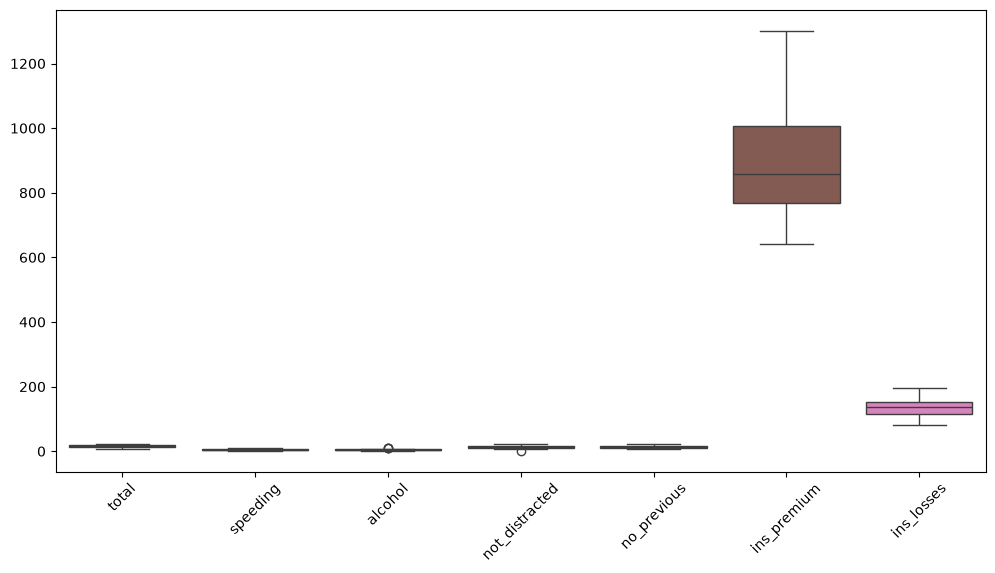

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns='abbrev'))
plt.xticks(rotation=45)
plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler

# 1. Sirf numeric columns select karein
features = df.drop(columns='abbrev')

# 2. StandardScaler apply karein
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)
# 3. Phir se DataFrame banayein
df_scaled = pd.DataFrame(scaled_data, columns=features.columns)


In [33]:
df_scaled.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
0,0.737446,1.168148,0.439938,1.002301,0.277692,-0.580083,0.430514
1,0.565936,1.212695,-0.211311,0.608532,0.807258,0.943258,-0.022900
2,0.688443,0.756709,0.187615,0.459357,1.033141,0.070876,-0.981778
3,1.619498,-0.483614,0.547408,1.676052,1.951700,-0.337701,0.321125
4,-0.928653,-0.399524,-0.891763,-0.594276,-0.891968,-0.048418,1.266178


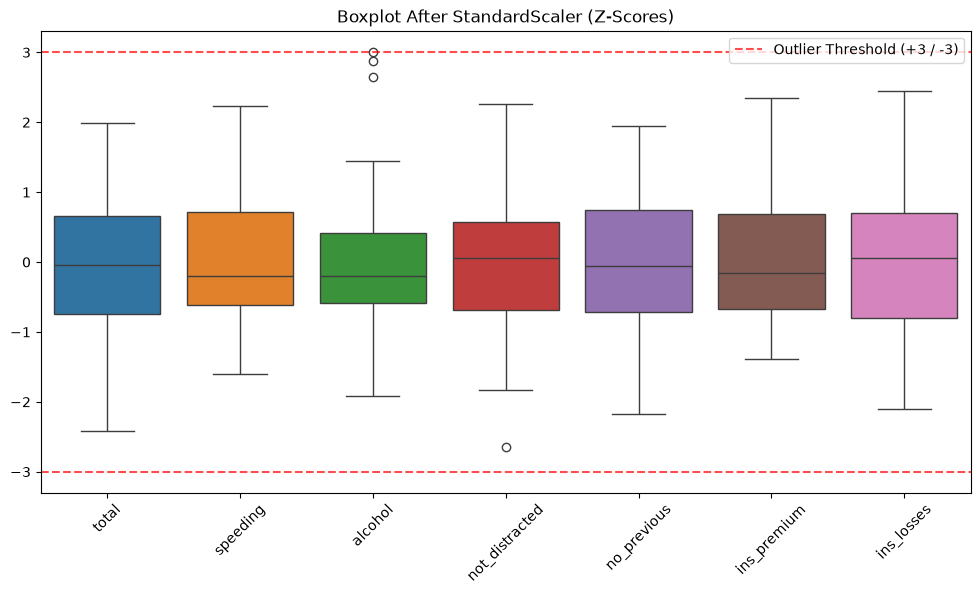

In [34]:
# 4. Boxplot plot karein
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled)
plt.xticks(rotation=45)
plt.title("Boxplot After StandardScaler (Z-Scores)")
plt.axhline(3, color='r', linestyle='--', alpha=0.7, label='Outlier Threshold (+3 / -3)')
plt.axhline(-3, color='r', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['speeding', 'alcohol', 'not_distracted', 'no_previous']]
y = df['total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression().fit(X_train, y_train)
lrg = model.predict(X_test)
print("R2 Score :",round(r2_score(y_test,lrg)*100,2),'%')

R2 Score : 88.94 %


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("R2 Score:", round(r2_score(y_test, y_pred_rf)*100,2),'%')

R2 Score: 87.67 %
